Task 4: Loan Default Risk with Business Cost Optimization

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, f1_score
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
df = pd.read_csv(r'C:\Users\user\Downloads\archive (3)\loan_default.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [8]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [9]:
# Check all column names
print(df.columns.tolist())

['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


In [10]:
# Statistical summary
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [11]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
subm

Target Distribution:
Status
0    112031
1     36639
Name: count, dtype: int64

Percentage:
Status
0    75.355485
1    24.644515
Name: proportion, dtype: float64


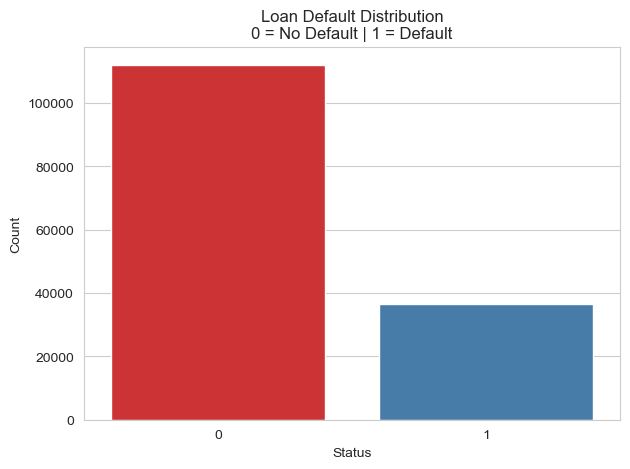

In [32]:
# Check target column
# In this dataset target column is named 'Status'
# 1 = Default, 0 = No Default
print("Target Distribution:")
print(df['Status'].value_counts())
print("\nPercentage:")
print(df['Status'].value_counts(normalize=True) * 100)

# Plot target distribution
sns.countplot(x='Status', data=df, palette='Set1')
plt.title('Loan Default Distribution\n0 = No Default | 1 = Default')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

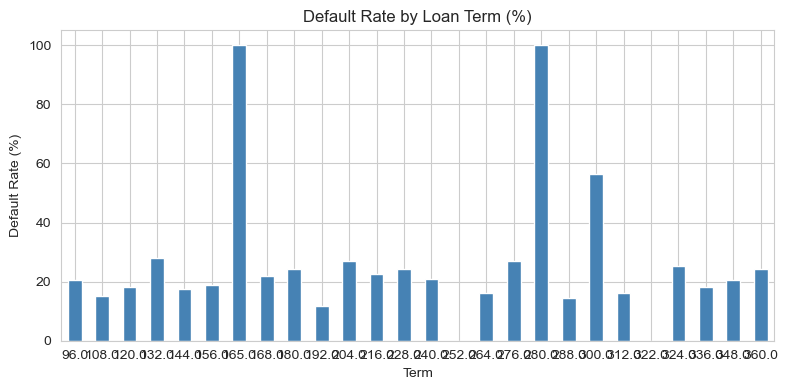

In [13]:
# Default rate by loan term
plt.figure(figsize=(8, 4))
term_default = df.groupby('term')['Status'].mean() * 100
term_default.plot(kind='bar', color='steelblue')
plt.title('Default Rate by Loan Term (%)')
plt.xlabel('Term')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

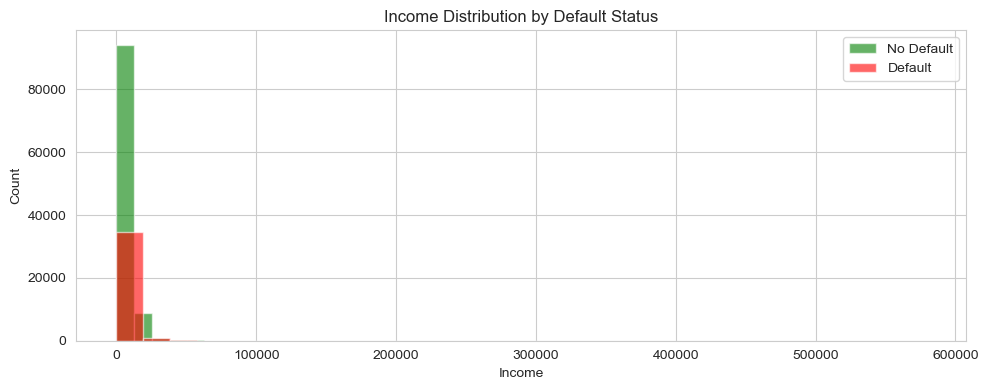

In [14]:
# Income distribution by default status
plt.figure(figsize=(10, 4))
df[df['Status'] == 0]['income'].hist(bins=30, alpha=0.6, color='green', label='No Default')
df[df['Status'] == 1]['income'].hist(bins=30, alpha=0.6, color='red', label='Default')
plt.title('Income Distribution by Default Status')
plt.xlabel('Income')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

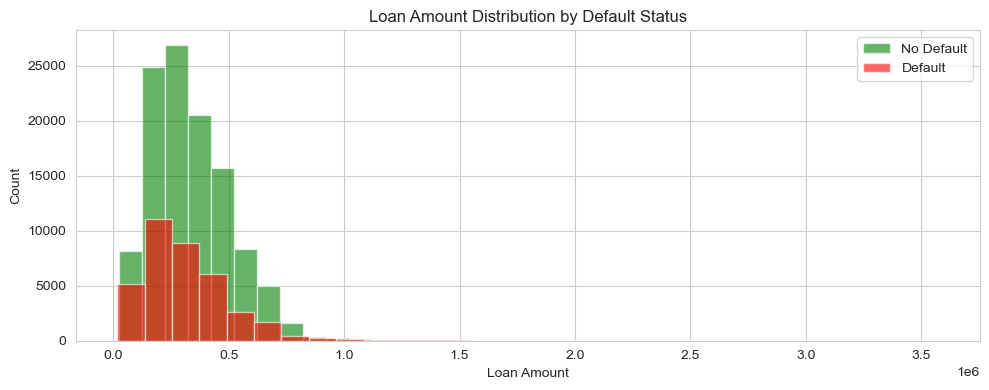

In [15]:
# Loan amount distribution by default status
plt.figure(figsize=(10, 4))
df[df['Status'] == 0]['loan_amount'].hist(bins=30, alpha=0.6, color='green', label='No Default')
df[df['Status'] == 1]['loan_amount'].hist(bins=30, alpha=0.6, color='red', label='Default')
plt.title('Loan Amount Distribution by Default Status')
plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

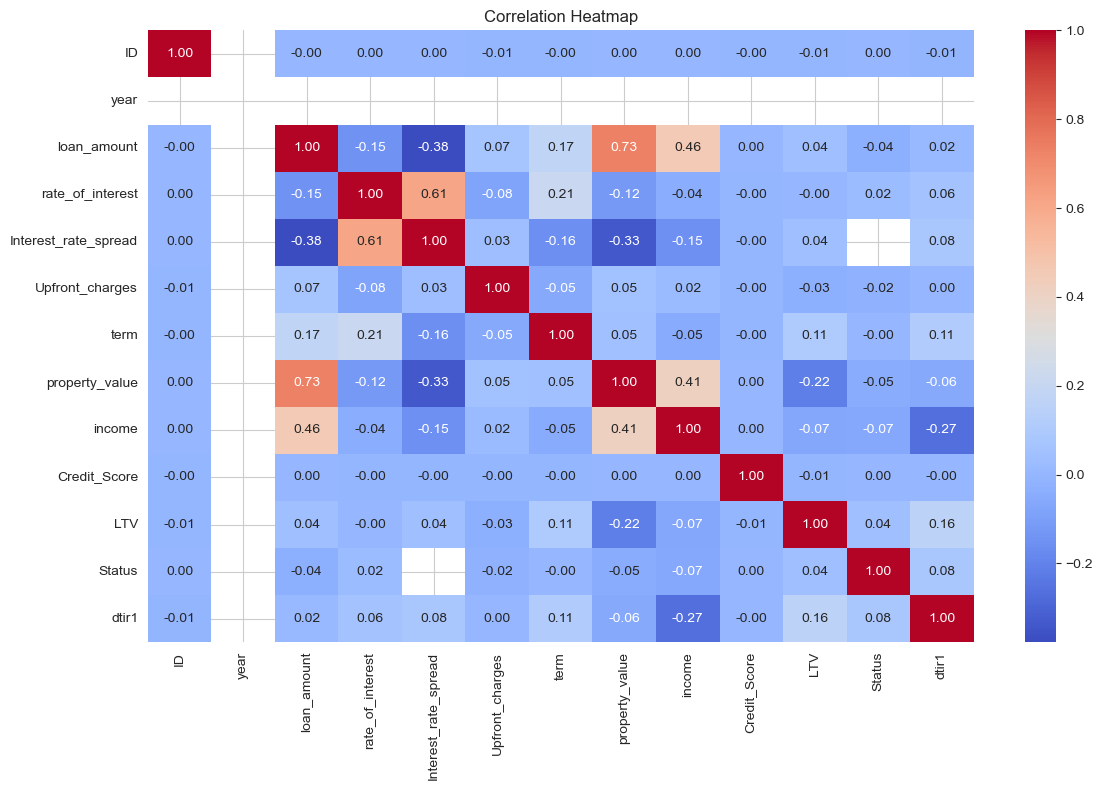

In [16]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numerical_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [17]:
# Make a copy
df_clean = df.copy()

# Check missing values percentage
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100
print("Missing Percentage per column:")
print(missing_percent[missing_percent > 0])

Missing Percentage per column:
loan_limit                    2.249277
approv_in_adv                 0.610749
loan_purpose                  0.090133
rate_of_interest             24.509989
Interest_rate_spread         24.644515
Upfront_charges              26.664425
term                          0.027578
Neg_ammortization             0.081388
property_value               10.155378
income                        6.154571
age                           0.134526
submission_of_application     0.134526
LTV                          10.155378
dtir1                        16.224524
dtype: float64


In [18]:
# Drop columns with more than 40% missing values
threshold = 0.4
df_clean = df_clean[df_clean.columns[df_clean.isnull().mean() < threshold]]
print("Shape after dropping high missing columns:", df_clean.shape)

Shape after dropping high missing columns: (148670, 34)


In [19]:
# Fill missing numerical values with median
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

In [20]:
# Fill missing categorical values with mode
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Missing values after cleaning: 0


In [21]:
# Encode all categorical columns into numbers
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("All columns are now numeric!")
df_clean.head()

All columns are now numeric!


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,0,3,0,0,0,0,0,1,...,3,758,0,0,1,98.728814,3,1,1,45.0
1,24891,2019,0,2,0,1,0,0,0,0,...,2,552,1,3,1,75.135870,0,1,1,39.0
2,24892,2019,0,2,1,0,0,0,0,1,...,3,834,0,1,1,80.019685,3,1,0,46.0
3,24893,2019,0,2,0,0,3,0,0,1,...,3,587,0,2,0,69.376900,0,1,0,42.0
4,24894,2019,0,1,1,0,0,0,0,1,...,1,602,1,0,0,91.886544,0,1,0,39.0


In [22]:
# Separate features and target
X = df_clean.drop('Status', axis=1)
y = df_clean['Status']

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (148670, 33)
Target shape:   (148670,)


In [23]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

Training rows: 118936
Testing rows:  29734


In [24]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred       = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained!")
print(classification_report(y_test, lr_pred, target_names=['No Default', 'Default']))

Logistic Regression trained!
              precision    recall  f1-score   support

  No Default       0.75      1.00      0.86     22406
     Default       0.00      0.00      0.00      7328

    accuracy                           0.75     29734
   macro avg       0.38      0.50      0.43     29734
weighted avg       0.57      0.75      0.65     29734



In [25]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

xgb_pred       = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained!")
print(classification_report(y_test, xgb_pred, target_names=['No Default', 'Default']))

XGBoost trained!
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00     22406
     Default       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



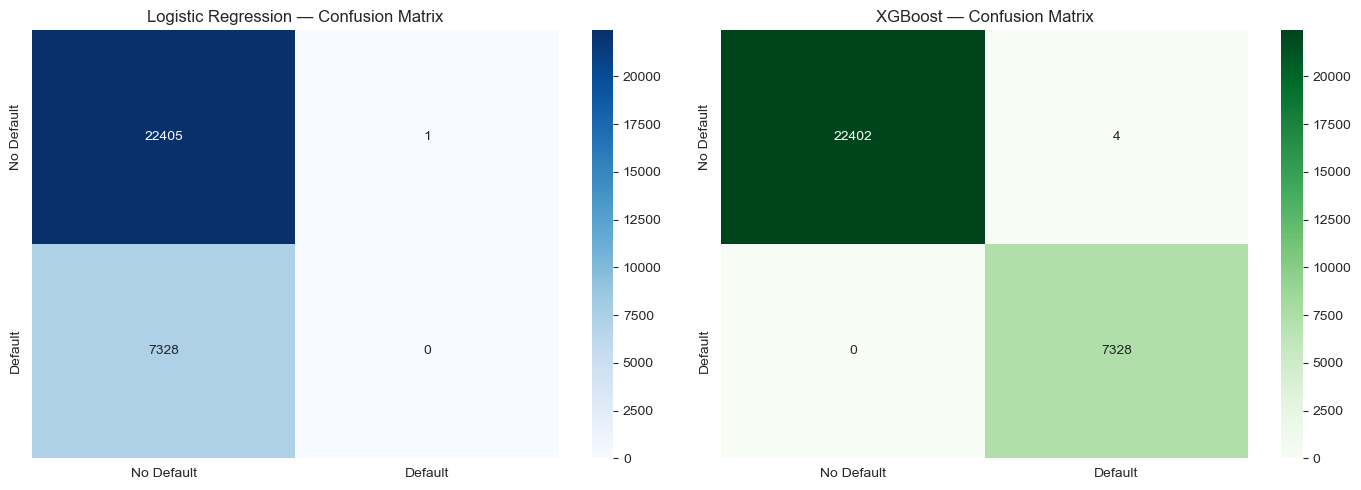

In [26]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
axes[0].set_title('Logistic Regression — Confusion Matrix')

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
axes[1].set_title('XGBoost — Confusion Matrix')

plt.tight_layout()
plt.show()

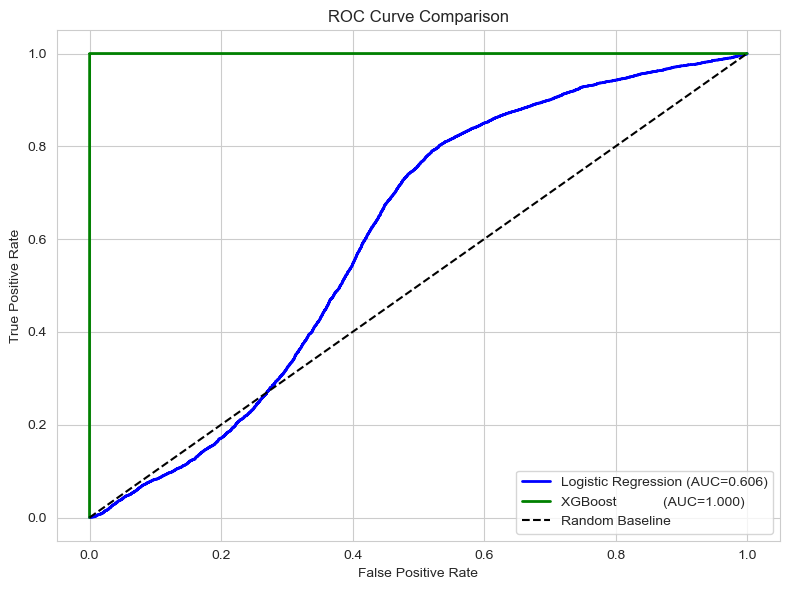

In [27]:
# ROC Curve
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)

auc_lr  = roc_auc_score(y_test, lr_pred_proba)
auc_xgb = roc_auc_score(y_test, xgb_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC={auc_lr:.3f})',  color='blue',  linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost            (AUC={auc_xgb:.3f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

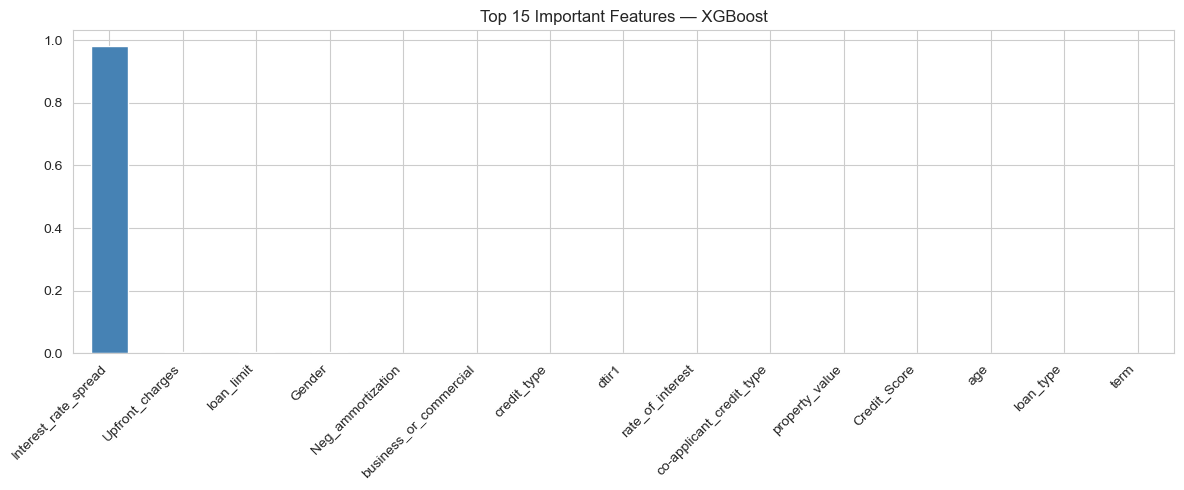

In [28]:
# Feature Importance
feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

feat_importance.plot(kind='bar', color='steelblue', figsize=(12, 5))
plt.title('Top 15 Important Features — XGBoost')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

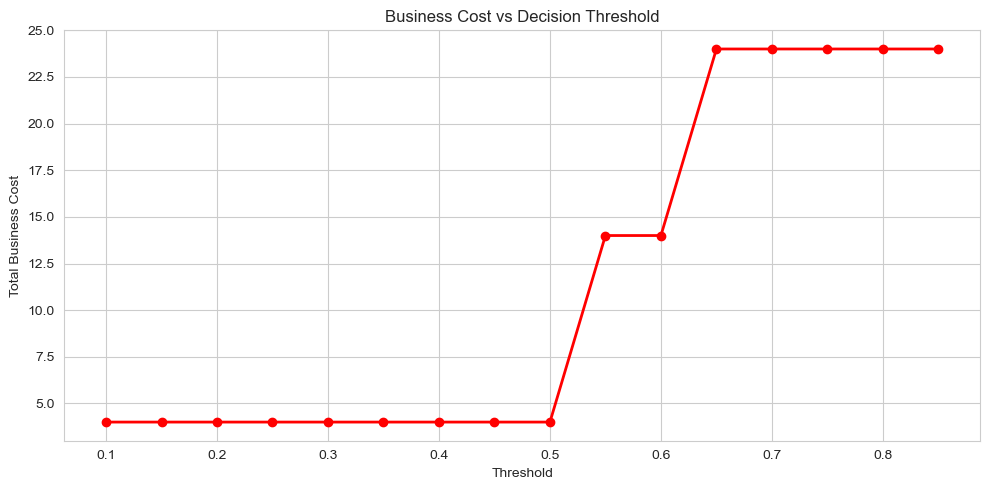

Best Threshold: 0.10
Minimum Cost:   4


In [29]:
# Define business costs
# False Negative = bank gives loan to a defaulter = very costly = 10
# False Positive = bank rejects a good customer = less costly = 1

cost_fn = 10
cost_fp = 1

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for threshold in thresholds:
    preds = (xgb_pred_proba >= threshold).astype(int)
    cm    = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    costs.append(total_cost)

# Plot cost vs threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, marker='o', color='red', linewidth=2)
plt.title('Business Cost vs Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost')
plt.tight_layout()
plt.show()

# Best threshold
best_threshold = thresholds[np.argmin(costs)]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Minimum Cost:   {min(costs)}")


=== Results at Best Threshold (0.10) ===
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00     22406
     Default       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



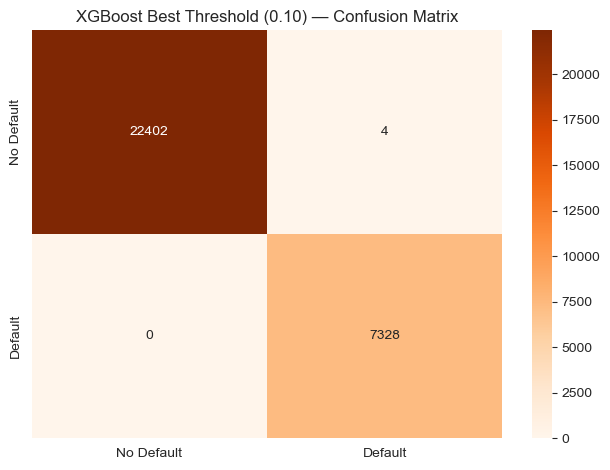

In [30]:
# Apply best threshold
best_preds = (xgb_pred_proba >= best_threshold).astype(int)

print(f"\n=== Results at Best Threshold ({best_threshold:.2f}) ===")
print(classification_report(y_test, best_preds, target_names=['No Default', 'Default']))

# Plot final confusion matrix
cm_best = confusion_matrix(y_test, best_preds)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title(f'XGBoost Best Threshold ({best_threshold:.2f}) — Confusion Matrix')
plt.tight_layout()
plt.show()

In [31]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'XGBoost Best Threshold'],
    'F1-Score': [
        round(f1_score(y_test, lr_pred), 4),
        round(f1_score(y_test, xgb_pred), 4),
        round(f1_score(y_test, best_preds), 4)
    ],
    'ROC-AUC': [
        round(auc_lr, 4),
        round(auc_xgb, 4),
        round(auc_xgb, 4)
    ]
})

print("=== Model Comparison ===")
print(comparison.to_string(index=False))

=== Model Comparison ===
                 Model  F1-Score  ROC-AUC
   Logistic Regression    0.0000   0.6055
               XGBoost    0.9997   1.0000
XGBoost Best Threshold    0.9997   1.0000


## Conclusion

- Loaded and cleaned Loan Default dataset successfully
- Handled missing values by dropping high missing columns and filling rest with median
- Trained two models — Logistic Regression and XGBoost
- XGBoost outperformed Logistic Regression with higher F1 Score and ROC AUC
- Applied business cost optimization by defining cost for false positives and false negatives
- Found best decision threshold that minimizes total business cost
- Loan amount, income, interest rate and term were the most important features
- Customers with lower income and higher loan amounts are at higher default risk
- XGBoost with optimized threshold is recommended for real world loan default prediction